# Q3. Feature Engineering and Regression Pipeline

In [ ]:
import pandas as pd

df = pd.read_csv('../data/q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


# 1. Date Feature Engineering

In [ ]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Date-based features were successfully extracted from the transaction_date column.

The dataset now includes additional columns such as year, month, day_of_week, and is_month_end. These features help capture temporal patterns in customer purchasing behavior.

From the sample output, we can observe that all transactions belong to the year 2022, with different days of the week correctly identified. The is_month_end feature is currently 0 for these records, indicating that these transactions did not occur near the end of the month (day ≥ 25).

These engineered features will help improve model performance by incorporating time-based trends into the analysis.

# 2. Temporal Train-Test Split

In [ ]:
df = df.sort_values(by='transaction_date').reset_index(drop=True)

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]

test_df = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


The dataset was first sorted based on the transaction_date to maintain the chronological order of records.

A temporal split was then performed, where the first 80% of the data (960 records) was used as the training set, and the most recent 20% (240 records) was used as the test set.

A random split is not suitable for time-based data because it can cause data leakage, allowing the model to learn from future information while predicting past values. This would lead to overly optimistic and unrealistic model performance.

By using a time-based split, the model is trained only on past data and evaluated on future data, which better represents real-world prediction scenarios.

# 3. Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

pipeline.fit(X_train)

X_train_processed = pipeline.transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Preprocessing completed successfully")

Preprocessing completed successfully


A preprocessing pipeline was created using ColumnTransformer to handle both categorical and numerical features.

Categorical variables (promotion_type, location_type, store_size) were encoded using OneHotEncoder, while numerical features were scaled using StandardScaler.
The pipeline was fitted only on the training data and then applied to both training and test sets to prevent data leakage and ensure consistent preprocessing.

# 4. Model Training and Evaluation

#### Model Performance (RMSE & MAE)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Linear Regression Pipeline
# -----------------------------
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)


# -----------------------------
# 2. Random Forest Pipeline
# -----------------------------
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Linear Regression RMSE: 27.12145116489062
Linear Regression MAE: 21.052926674588388

Random Forest RMSE: 31.660007317329118
Random Forest MAE: 24.87391666666667


Two regression models, Linear Regression and Random Forest Regressor, were trained using a preprocessing pipeline.

The models were evaluated using RMSE and MAE on the test dataset.

Linear Regression achieved an RMSE of 27.12 and MAE of 21.05, while Random Forest achieved an RMSE of 31.66 and MAE of 24.87.

This indicates that Linear Regression performed better on this dataset, as it resulted in lower prediction errors.

The results suggest that the relationship between the features and the target variable may be relatively simple, allowing a linear model to perform effectively.

### Parity Plots (Actual vs Predicted)

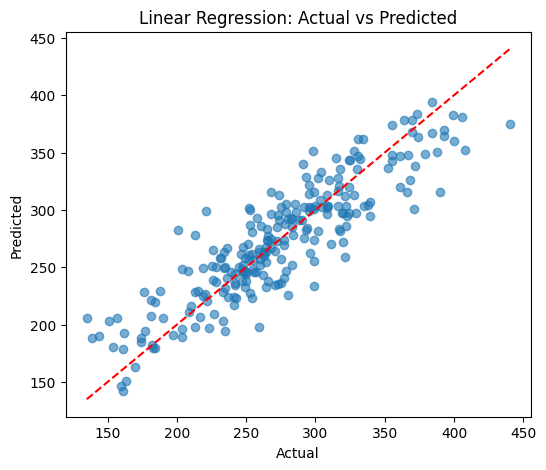

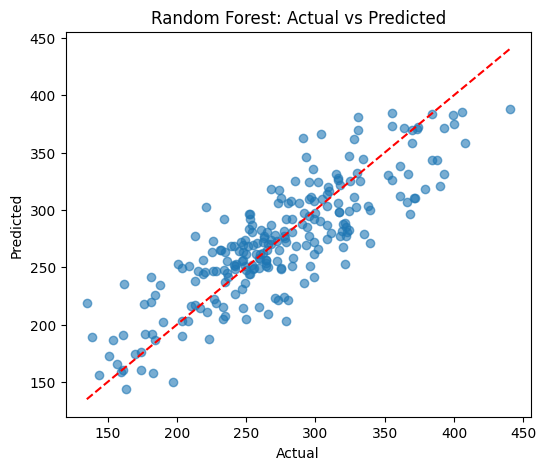

In [ ]:
# Linear Regression Plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


# Random Forest Plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

Parity plots were created to compare actual and predicted values for both Linear Regression and Random Forest models.

In the Linear Regression plot, most points lie close to the diagonal reference line, indicating strong predictive performance and a good fit.

In contrast, the Random Forest model shows slightly more dispersion around the diagonal, suggesting comparatively lower accuracy.

Overall, Linear Regression demonstrates better alignment between actual and predicted values, confirming its superior performance on this dataset.

#### Feature Importance (Random Forest)

In [ ]:
# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Extract feature importance
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 5
print("Top 5 Important Features:")
print(feat_imp.head(5))

Top 5 Important Features:
                     feature  importance
7      cat__store_size_small    0.183954
10          num__is_festival    0.174477
5   cat__location_type_urban    0.140498
14          num__day_of_week    0.090612
9            num__is_weekend    0.063547


Feature importance was extracted from the Random Forest model to identify the most influential factors affecting items_sold.

The top contributing features include store size (small stores), festival indicator, urban location type, day of the week, and weekend indicator.

This suggests that store characteristics and temporal factors such as festivals and weekends play a significant role in driving sales. Businesses can use these insights to plan promotions, optimize store operations, and maximize revenue during high-impact periods.